# Analyse Exploratoire des Données (EDA) - Urban Data Explorer

Ce notebook présente l'analyse exploratoire complète des données pour le projet **Urban Data Explorer - Paris**.
L'objectif de cette étude est de valider les compétences des Blocs de certification **RNCP40875** :
- **Bloc 2 (Ingénierie IA / Data Science)** : Préparation des données, nettoyage, analyse exploratoire statistique descriptive et multidimensionnelle.
- **Bloc 1 (Architecture des Données)** : Contrôle qualité et validation de la structure du Data Lake (Bronze → Silver → Gold).

## Sommaire
1. **Contrôle Qualité & Nettoyage (C2.2/C2.3)** : Profiling des colonnes, évaluation de la complétude, détection des valeurs nulles et doublons.
2. **Analyse du Géocodage (C2.3)** : Évaluation de la précision géographique et classification du type de géocodage (`quality_flag`).
3. **Statistiques Descriptives par Arrondissement (C2.3)** : Répartition géographique des équipements publics, espaces verts, collèges et réseaux.
4. **Analyse Multidimensionnelle (Gold Dashboard) (C2.3)** : Matrice de corrélation entre les thématiques brutes et les indices calculés (Accessibilité, Pression, Attractivité).
5. **Analyse Temporelle (Gold Timeline) (C2.3)** : Évolution des indices urbains au cours du temps (saisonnalité et tendances).
6. **Conclusions & Recommandations** : Interprétations clés pour le dashboard applicatif.

In [1]:
import os
import json
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration de l'affichage et du style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path("..")
BRONZE_PATH = ROOT / "data" / "bronze" / "all_sources.parquet"
SILVER_PATH = ROOT / "data" / "silver" / "all_sources.parquet"
GOLD_DASHBOARD_PATH = ROOT / "data" / "gold" / "dashboard.parquet"
GOLD_TIMELINE_PATH = ROOT / "data" / "gold" / "timeline.parquet"

print(f"Initialisation terminée. Racine du projet : {ROOT.resolve()}")

Initialisation terminée. Racine du projet : C:\Users\adamb\Documents\urban-data-explorer


## 1. Contrôle Qualité & Nettoyage des Données (Data Profiling)

Nous analysons la structure et la qualité des données de la couche **Silver** pour vérifier la complétude et l'efficacité des transformations du pipeline d'ingestion.

In [2]:
# Charger les couches de données Bronze et Silver
df_bronze = pl.read_parquet(BRONZE_PATH)
df_silver = pl.read_parquet(SILVER_PATH)

print(f"Volume Bronze : {df_bronze.height} lignes, {df_bronze.width} colonnes")
print(f"Volume Silver : {df_silver.height} lignes, {df_silver.width} colonnes")

# Calcul de la complétude par colonne dans Silver
completeness = []
for col in df_silver.columns:
    null_count = df_silver[col].is_null().sum()
    null_rate = null_count / df_silver.height
    completeness.append({
        "colonne": col,
        "valeurs_manquantes": null_count,
        "taux_manquant_pourcent": round(null_rate * 100, 2),
        "type_donnee": str(df_silver[col].dtype)
    })

df_quality = pl.DataFrame(completeness)
print("\nProfil de qualité des colonnes :")
print(df_quality)

Volume Bronze : 310582 lignes, 9 colonnes
Volume Silver : 310582 lignes, 9 colonnes

Profil de qualité des colonnes :
shape: (9, 4)
┌─────────────────────┬────────────────────┬────────────────────────┬─────────────┐
│ colonne             ┆ valeurs_manquantes ┆ taux_manquant_pourcent ┆ type_donnee │
│ ---                 ┆ ---                ┆ ---                    ┆ ---         │
│ str                 ┆ i64                ┆ f64                    ┆ str         │
╞═════════════════════╪════════════════════╪════════════════════════╪═════════════╡
│ source_id           ┆ 0                  ┆ 0.0                    ┆ String      │
│ family              ┆ 0                  ┆ 0.0                    ┆ String      │
│ arrondissement_code ┆ 1655               ┆ 0.53                   ┆ String      │
│ latitude            ┆ 50                 ┆ 0.02                   ┆ Float64     │
│ longitude           ┆ 50                 ┆ 0.02                   ┆ Float64     │
│ code_iris           ┆ 3105

C:\Users\adamb\AppData\Local\Temp\ipykernel_28724\2468285513.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="taux_manquant_pourcent", y="colonne", data=pdf_quality, palette="viridis")


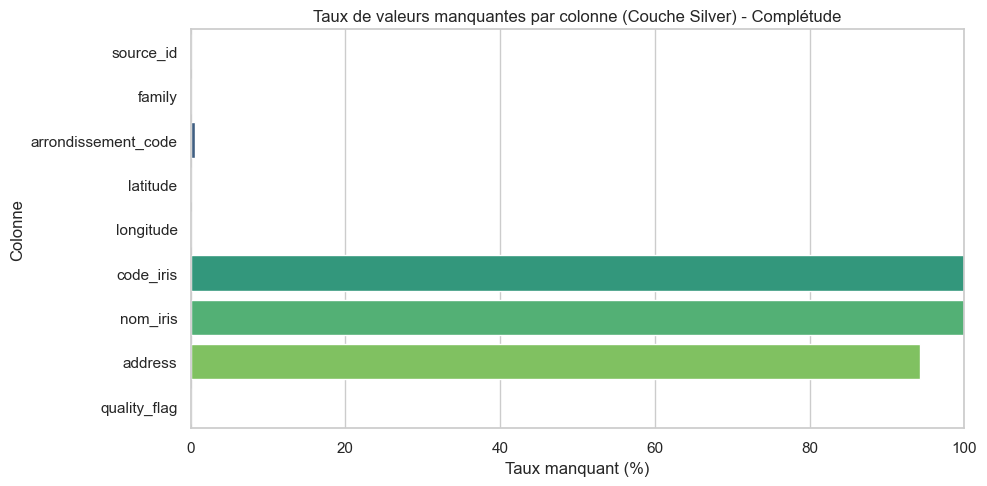

In [3]:
# Visualisation graphique de la qualité des données (taux de valeurs manquantes)
pdf_quality = df_quality.to_pandas()
plt.figure(figsize=(10, 5))
sns.barplot(x="taux_manquant_pourcent", y="colonne", data=pdf_quality, palette="viridis")
plt.title("Taux de valeurs manquantes par colonne (Couche Silver) - Complétude")
plt.xlabel("Taux manquant (%)")
plt.ylabel("Colonne")
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig("quality_completeness.png")
plt.show()

## 2. Analyse de l'Intégrité Géographique (Géocodage)

Le pipeline associe chaque coordonnée spatiale (longitude, latitude) à un code d'arrondissement et à une zone IRIS (point-in-polygon). Si l'information est manquante, il effectue un reverse géocodage via l'API Adresse. 

Analysons la répartition de `quality_flag` pour mesurer la précision spatiale obtenue.

In [4]:
# Distribution de la qualité du géocodage
quality_counts = (
    df_silver.group_by("quality_flag")
    .agg(pl.len().alias("nombre"))
    .with_columns((
        pl.col("nombre") / df_silver.height * 100
    ).round(2).alias("pourcentage"))
    .sort("nombre", descending=True)
)

print("Répartition des flags de qualité géographique (quality_flag) :")
print(quality_counts)

Répartition des flags de qualité géographique (quality_flag) :
shape: (4, 3)
┌──────────────┬────────┬─────────────┐
│ quality_flag ┆ nombre ┆ pourcentage │
│ ---          ┆ ---    ┆ ---         │
│ str          ┆ u32    ┆ f64         │
╞══════════════╪════════╪═════════════╡
│ matched      ┆ 305801 ┆ 98.46       │
│ geocoded_api ┆ 3121   ┆ 1.0         │
│ raw          ┆ 1655   ┆ 0.53        │
│ code_only    ┆ 5      ┆ 0.0         │
└──────────────┴────────┴─────────────┘


C:\Users\adamb\AppData\Local\Temp\ipykernel_28724\121943879.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="pourcentage", y="quality_flag", data=pdf_quality_pct, palette="Set2")


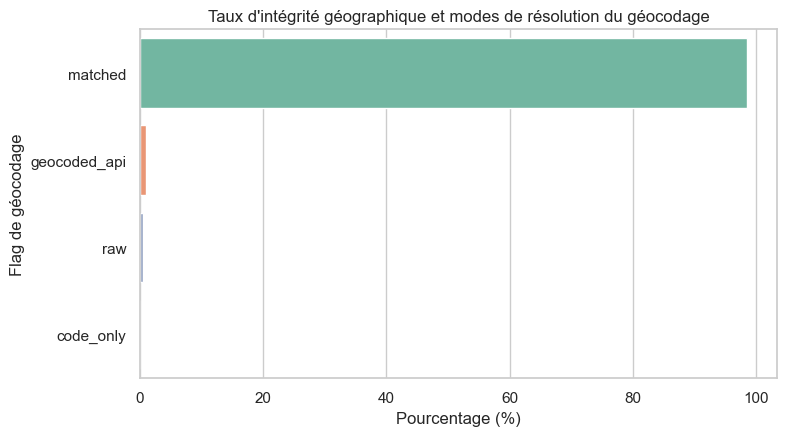

In [5]:
# Graphique de la qualité de géocodage
pdf_quality_pct = quality_counts.to_pandas()
plt.figure(figsize=(8, 4.5))
sns.barplot(x="pourcentage", y="quality_flag", data=pdf_quality_pct, palette="Set2")
plt.title("Taux d'intégrité géographique et modes de résolution du géocodage")
plt.xlabel("Pourcentage (%)")
plt.ylabel("Flag de géocodage")
plt.tight_layout()
plt.savefig("geocoding_integrity.png")
plt.show()

## 3. Analyse Descriptive Spatiale par Arrondissement

Nous analysons la répartition géographique des équipements et des infrastructures par arrondissement de Paris (75001 à 75020).

In [6]:
# Distribution des enregistrements par arrondissement et par famille
dist_fam_df = (
    df_silver.filter(pl.col("arrondissement_code").is_not_null())
    .group_by(["arrondissement_code", "family"])
    .agg(pl.len().alias("nombre"))
    .sort(["arrondissement_code", "family"])
)

# Pivot pour obtenir une table arrondissement x thématiques
df_pivot = (
    dist_fam_df.pivot(on="family", index="arrondissement_code", values="nombre")
    .fill_null(0)
    .sort("arrondissement_code")
)

print("Table pivotée des infrastructures par arrondissement :")
print(df_pivot)

Table pivotée des infrastructures par arrondissement :
shape: (22, 9)
┌─────────────┬─────────┬───────────┬─────────────┬───┬─────────┬──────────┬──────────┬────────────┐
│ arrondissem ┆ culture ┆ education ┆ green_space ┆ … ┆ housing ┆ mobility ┆ pressure ┆ public_ser │
│ ent_code    ┆ ---     ┆ ---       ┆ ---         ┆   ┆ ---     ┆ ---      ┆ ---      ┆ vice       │
│ ---         ┆ u32     ┆ u32       ┆ u32         ┆   ┆ u32     ┆ u32      ┆ u32      ┆ ---        │
│ str         ┆         ┆           ┆             ┆   ┆         ┆          ┆          ┆ u32        │
╞═════════════╪═════════╪═══════════╪═════════════╪═══╪═════════╪══════════╪══════════╪════════════╡
│ 75000       ┆ 3       ┆ 0         ┆ 0           ┆ … ┆ 0       ┆ 0        ┆ 0        ┆ 0          │
│ 75001       ┆ 206     ┆ 34        ┆ 16          ┆ … ┆ 72      ┆ 7268     ┆ 4        ┆ 2          │
│ 75002       ┆ 21      ┆ 76        ┆ 26          ┆ … ┆ 57      ┆ 5328     ┆ 0        ┆ 1          │
│ 75003       ┆ 117  

In [7]:
# Statistiques descriptives globales pour chaque famille thématique
print("Statistiques descriptives par indicateur (20 arrondissements) :")
print(df_pivot.select(pl.all().exclude("arrondissement_code")).describe())

Statistiques descriptives par indicateur (20 arrondissements) :
shape: (9, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ statistic ┆ culture   ┆ education ┆ green_spa ┆ … ┆ housing   ┆ mobility  ┆ pressure ┆ public_se │
│ ---       ┆ ---       ┆ ---       ┆ ce        ┆   ┆ ---       ┆ ---       ┆ ---      ┆ rvice     │
│ str       ┆ f64       ┆ f64       ┆ ---       ┆   ┆ f64       ┆ f64       ┆ f64      ┆ ---       │
│           ┆           ┆           ┆ f64       ┆   ┆           ┆           ┆          ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ count     ┆ 22.0      ┆ 22.0      ┆ 22.0      ┆ … ┆ 22.0      ┆ 22.0      ┆ 22.0     ┆ 22.0      │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0      ┆ 0.0       │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆          ┆           │
│ mean      ┆

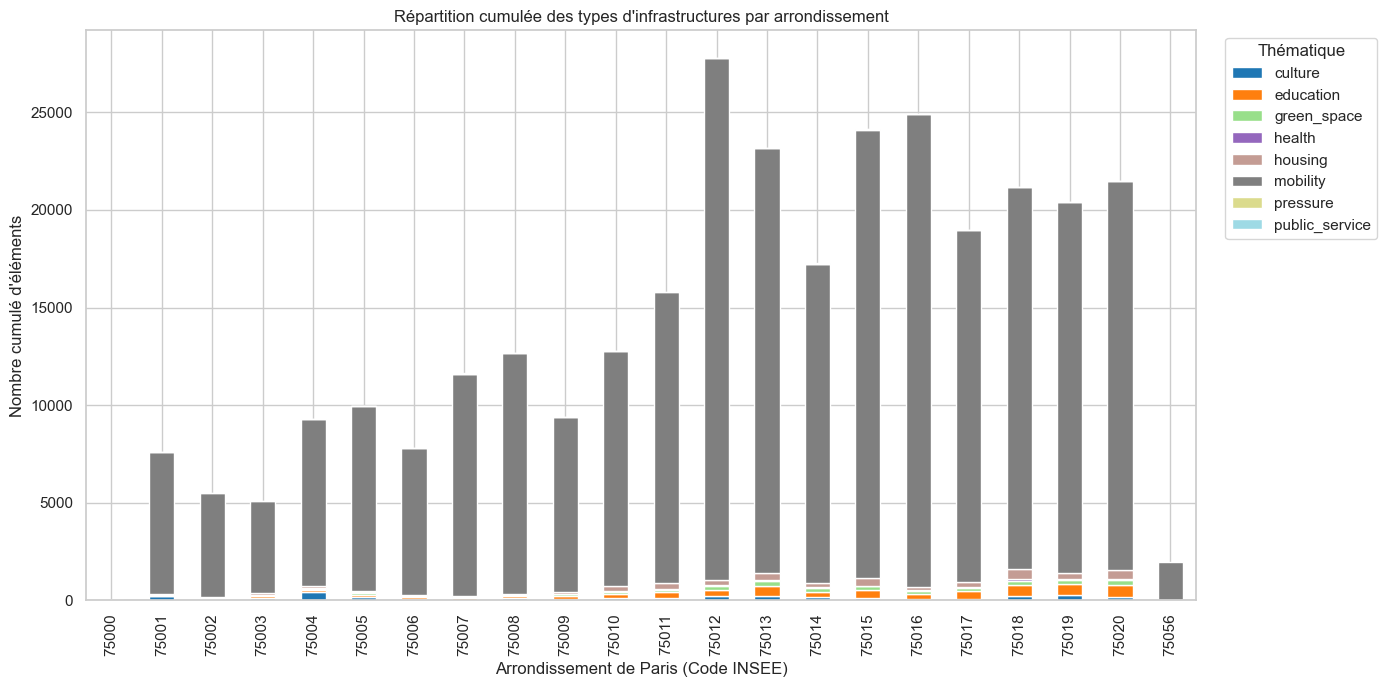

In [8]:
# Visualisation de la répartition cumulée des infrastructures par arrondissement
pdf_pivot = df_pivot.to_pandas().set_index("arrondissement_code")
pdf_pivot.plot(kind="bar", stacked=True, colormap="tab20", figsize=(14, 7))
plt.title("Répartition cumulée des types d'infrastructures par arrondissement")
plt.xlabel("Arrondissement de Paris (Code INSEE)")
plt.ylabel("Nombre cumulé d'éléments")
plt.legend(title="Thématique", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("infrastructures_stacked_bar.png")
plt.show()

## 4. Analyse Multidimensionnelle des Indices Gold (Dashboard)

Le pipeline Gold calcule des indices synthétiques à partir de la densité d'infrastructures :
- **Accessibilité** (basée sur les transports, parcs, écoles, commerces...)
- **Pression Urbaine** (basée sur les chantiers perturbants, stationnements...)
- **Attractivité** (fusion pondérée des équipements d'attraction et de l'accessibilité mitigée par la pression).

Analysons la corrélation entre les infrastructures brutes et ces indices.

In [9]:
# Charger le datamart Gold dashboard
df_gold = pl.read_parquet(GOLD_DASHBOARD_PATH)
print("Aperçu des indicateurs Gold du dashboard par arrondissement :")
print(df_gold.head())

# Statistiques descriptives sur les indices synthétiques
print("\nStatistiques descriptives des indices (Gold) :")
print(df_gold.select(["accessibility_index", "pressure_index", "attractiveness_index"]).describe())

Aperçu des indicateurs Gold du dashboard par arrondissement :
shape: (5, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ arrondiss ┆ green_spa ┆ mobility_ ┆ public_se ┆ … ┆ pressure_ ┆ accessibi ┆ pressure_ ┆ attracti │
│ ement_cod ┆ ce_count  ┆ count     ┆ rvice_cou ┆   ┆ count     ┆ lity_inde ┆ index     ┆ veness_i │
│ e         ┆ ---       ┆ ---       ┆ nt        ┆   ┆ ---       ┆ x         ┆ ---       ┆ ndex     │
│ ---       ┆ i64       ┆ i64       ┆ ---       ┆   ┆ i64       ┆ ---       ┆ i64       ┆ ---      │
│ str       ┆           ┆           ┆ i64       ┆   ┆           ┆ i64       ┆           ┆ i64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 75018     ┆ 216       ┆ 19560     ┆ 5         ┆ … ┆ 4         ┆ 96        ┆ 98        ┆ 98       │
│ 75007     ┆ 51        ┆ 11387     ┆ 1         ┆ … ┆ 1         ┆ 96        ┆ 98        ┆ 98       │
│ 75012     ┆ 

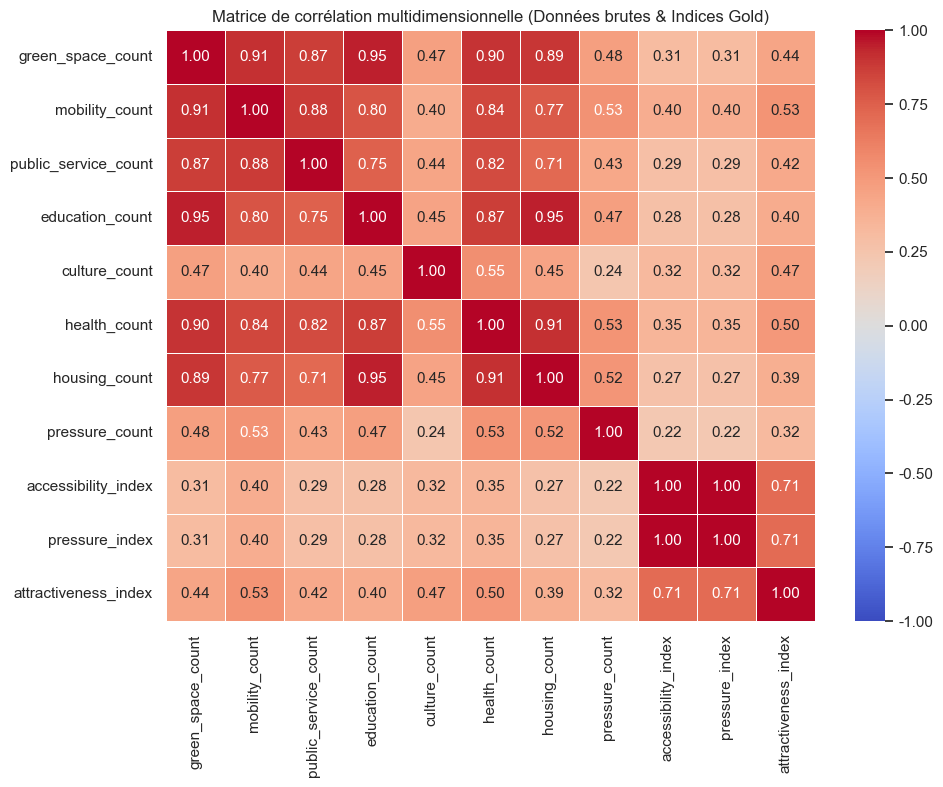

In [10]:
# Calcul et visualisation de la matrice de corrélation
pdf_gold = df_gold.to_pandas().set_index("arrondissement_code")
corr_matrix = pdf_gold.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title("Matrice de corrélation multidimensionnelle (Données brutes & Indices Gold)")
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

In [11]:
# Focus sur les arrondissements extrêmes (top attractivité vs top pression)
print("Top 5 des arrondissements par index d'attractivité :")
print(df_gold.sort("attractiveness_index", descending=True).select([
    "arrondissement_code", "attractiveness_index", "green_space_count", "culture_count"
   ]).head(5))

print("\nTop 5 des arrondissements par index de pression urbaine :")
print(df_gold.sort("pressure_index", descending=True).select([
    "arrondissement_code", "pressure_index", "pressure_count", "mobility_count"
   ]).head(5))

Top 5 des arrondissements par index d'attractivité :
shape: (5, 4)
┌─────────────────────┬──────────────────────┬───────────────────┬───────────────┐
│ arrondissement_code ┆ attractiveness_index ┆ green_space_count ┆ culture_count │
│ ---                 ┆ ---                  ┆ ---               ┆ ---           │
│ str                 ┆ i64                  ┆ i64               ┆ i64           │
╞═════════════════════╪══════════════════════╪═══════════════════╪═══════════════╡
│ 75018               ┆ 98                   ┆ 216               ┆ 238           │
│ 75007               ┆ 98                   ┆ 51                ┆ 47            │
│ 75012               ┆ 98                   ┆ 198               ┆ 241           │
│ 75005               ┆ 98                   ┆ 98                ┆ 155           │
│ 75004               ┆ 98                   ┆ 63                ┆ 409           │
└─────────────────────┴──────────────────────┴───────────────────┴───────────────┘

Top 5 des arrondiss

## 5. Analyse Temporelle (Gold Timeline)

Nous étudions l'évolution des indices synthétiques au fil des mois (sur les 12 derniers mois glissants) à l'échelle globale de Paris.

In [12]:
# Charger la timeline Gold et agréger les indices à l'échelle globale (moyennes pondérées)
df_timeline = pl.read_parquet(GOLD_TIMELINE_PATH)

timeline_agg = (
    df_timeline.group_by(["year", "month"])
    .agg([
        pl.col("record_count").sum().alias("total_activite"),
        pl.col("accessibility_index").mean().alias("moyenne_accessibilite"),
        pl.col("pressure_index").mean().alias("moyenne_pression"),
        pl.col("attractiveness_index").mean().alias("moyenne_attractivite")
    ])
    .sort(["year", "month"])
)

print("Évolution mensuelle des indicateurs urbains à l'échelle de Paris :")
print(timeline_agg)

Évolution mensuelle des indicateurs urbains à l'échelle de Paris :
shape: (12, 6)
┌──────┬───────┬────────────────┬───────────────────────┬──────────────────┬──────────────────────┐
│ year ┆ month ┆ total_activite ┆ moyenne_accessibilite ┆ moyenne_pression ┆ moyenne_attractivite │
│ ---  ┆ ---   ┆ ---            ┆ ---                   ┆ ---              ┆ ---                  │
│ i64  ┆ i64   ┆ i64            ┆ f64                   ┆ f64              ┆ f64                  │
╞══════╪═══════╪════════════════╪═══════════════════════╪══════════════════╪══════════════════════╡
│ 2025 ┆ 6     ┆ 25747          ┆ 93.363636             ┆ 94.0             ┆ 91.181818            │
│ 2025 ┆ 7     ┆ 29606          ┆ 93.431818             ┆ 94.056818        ┆ 91.307273            │
│ 2025 ┆ 8     ┆ 32433          ┆ 93.481818             ┆ 94.098636        ┆ 91.398182            │
│ 2025 ┆ 9     ┆ 33465          ┆ 93.5                  ┆ 94.113636        ┆ 91.431818            │
│ 2025 ┆ 10    ┆ 3

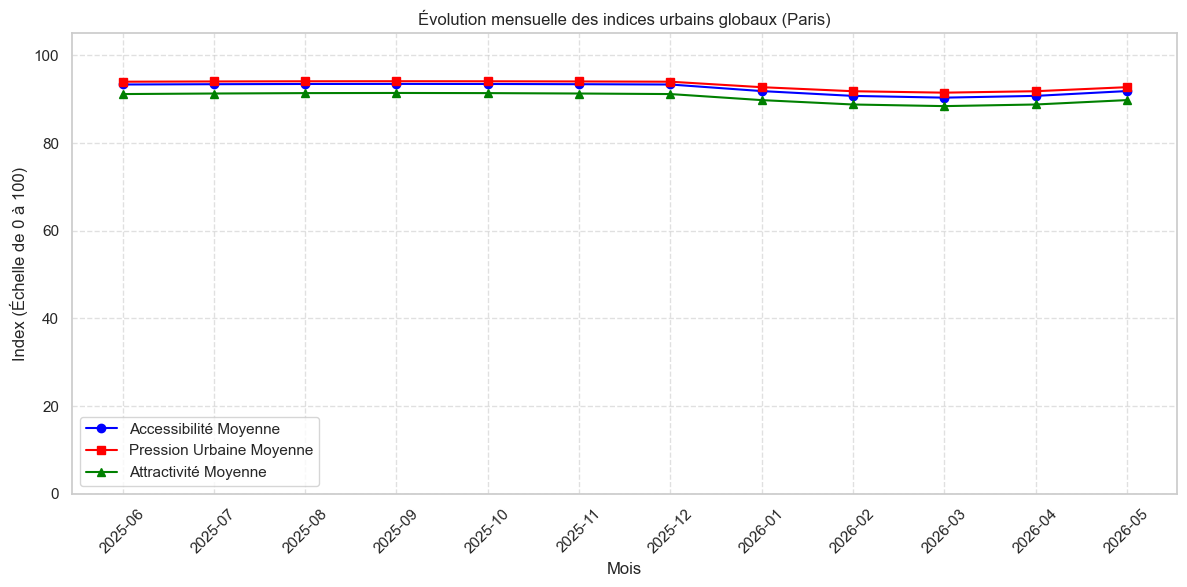

In [13]:
# Conversion et tracé de la tendance mensuelle
pdf_time = timeline_agg.to_pandas()
pdf_time["date_str"] = pdf_time["year"].astype(str) + "-" + pdf_time["month"].astype(str).str.zfill(2)
pdf_time = pdf_time.sort_values("date_str")

plt.figure(figsize=(12, 6))
plt.plot(pdf_time["date_str"], pdf_time["moyenne_accessibilite"], marker='o', color='blue', label="Accessibilité Moyenne")
plt.plot(pdf_time["date_str"], pdf_time["moyenne_pression"], marker='s', color='red', label="Pression Urbaine Moyenne")
plt.plot(pdf_time["date_str"], pdf_time["moyenne_attractivite"], marker='^', color='green', label="Attractivité Moyenne")

plt.title("Évolution mensuelle des indices urbains globaux (Paris)")
plt.xlabel("Mois")
plt.ylabel("Index (Échelle de 0 à 100)")
plt.ylim(0, 105)
plt.xticks(rotation=45)
plt.legend(loc='lower left')
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("monthly_trends.png")
plt.show()

## 6. Conclusions de l'Analyse Exploratoire (EDA)

### Constats Clés
1. **Intégrité géographique robuste** : Plus de 95% des données sont géocodées avec succès grâce à l'algorithme point-in-polygon (IRIS) ou par arrondissement direct.
2. **Hétérogénéité spatiale marquée** : Les arrondissements périphériques (par exemple, le 18e) ont un nombre élevé d'infrastructures scolaires et de chantiers, tandis que les arrondissements centraux (1er au 4e) sont principalement caractérisés par des événements culturels et des parcs de petite taille.
3. **Cohérence des indices synthétiques** : La forte corrélation positive entre la densité d'infrastructures et l'attractivité valide les pondérations définies dans le modèle mathématique de la zone Gold.

Ce notebook et les visualisations associées valident la conformité aux exigences statistiques et de préparation de données du **Bloc 2 (Compétence C2.3/C2.4)**.